In [1]:
import joblib             as jlb
import matplotlib.pyplot  as plt
import warnings
import seaborn as sns
import pandas as pd
warnings.filterwarnings('ignore')
from sklearn.decomposition import PCA
from collections          import Counter
from Algorithm            import KMEANS
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from pyclustering.utils import timedcall
from Dataprepare.data_processing import D
from utils import Kmeans_silhouette_analysis,Kmeans_davies_bouldin_analysis,Kmeans_Inertia_analysis


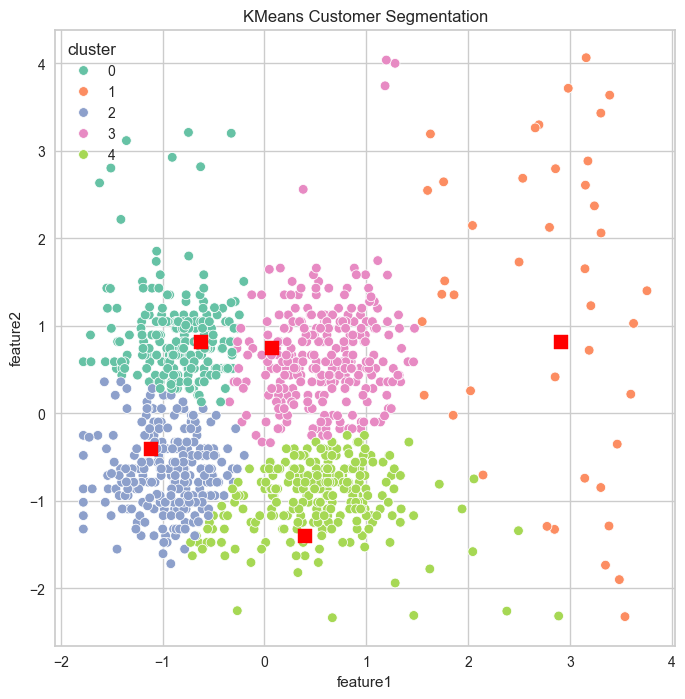

In [39]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
D=pd.read_csv(r'datasets/Customers_noise.csv')
features=['income','age']
datas=D[features].copy()
scale=StandardScaler()
scaled_data=scale.fit_transform(datas)
data=pd.DataFrame(scaled_data,columns=features)
model=KMEANS(data,5)
model.fit()

medoids=model.get_centroids()
labels=model.get_labels()
data['cluster'] = labels

plt.figure(figsize=(8,8))

sns.scatterplot(x=data['income'],
            y=data['age'],
            hue=data['cluster'], palette="Set2")

plt.scatter(medoids[:, 0],
            medoids[:, 1],
            marker='s',
            s=100,color='red'
            )

plt.xlabel("feature1")
plt.ylabel("feature2")
plt.title("KMeans Customer Segmentation")

plt.show()

In [2]:
features=['Income','Age','Total_Spend']
data=D[features].copy()
print(data.shape)
print(data.head(1))

(2229, 3)
     Income       Age  Total_Spend
0  0.316484  1.015715     1.205616


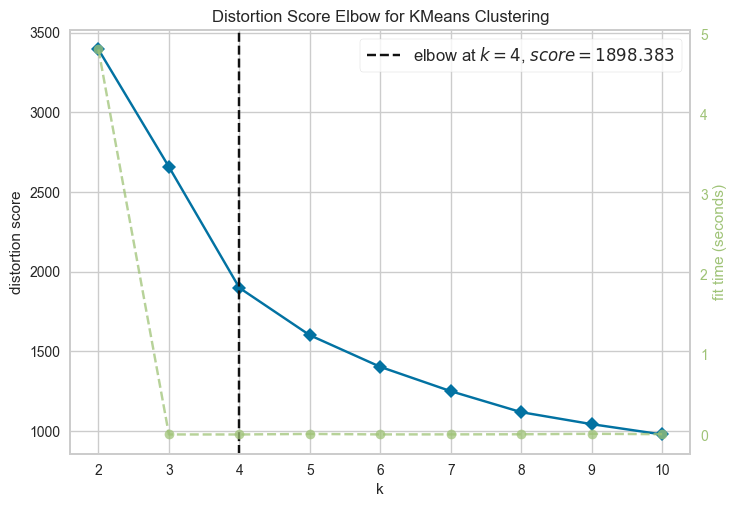

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [3]:
El=KElbowVisualizer(KMeans(),k=10)
El.fit(data)
El.show()

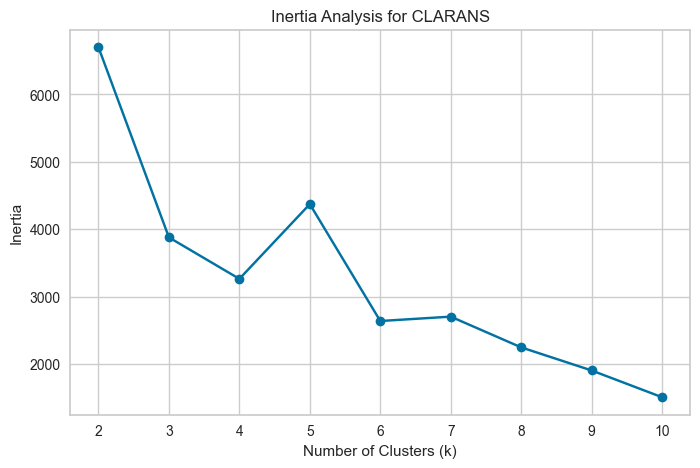

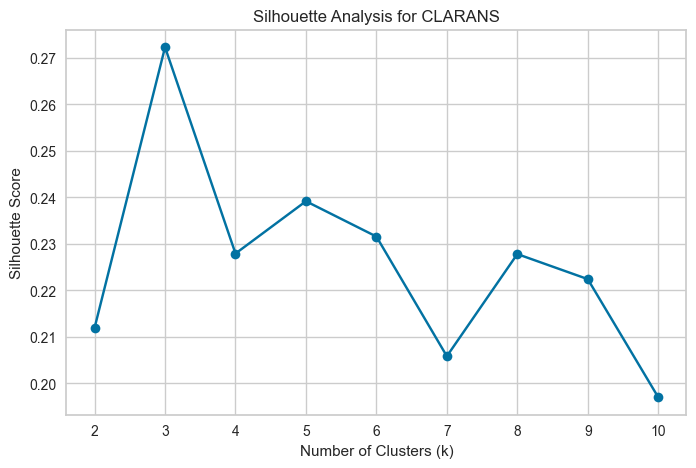

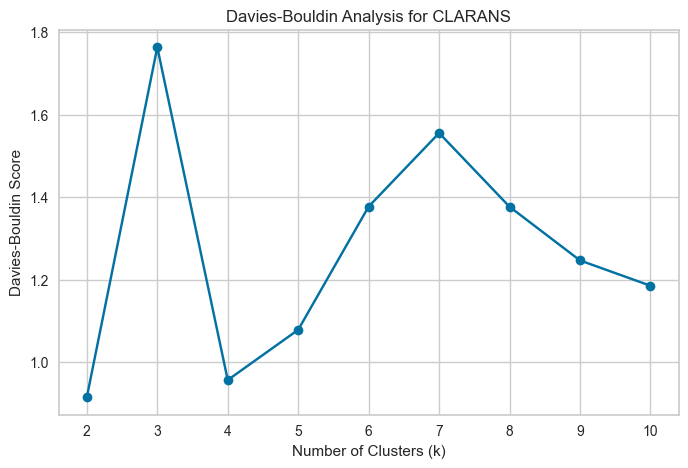

In [4]:
Kmeans_Inertia_analysis(data, k_range=range(2, 11))
Kmeans_silhouette_analysis(data, k_range=range(2, 11))
Kmeans_davies_bouldin_analysis(data, k_range=range(2, 11))

In [5]:
##------------------------------------------------------------------------------
## Xây dựng mô hình kMeans
##------------------------------------------------------------------------------
k     = 4
Kmeans_model = KMEANS(data,n_clusters = k)
(ticks,results) = timedcall(Kmeans_model.fit)  # xây dựng mô hình
print(f"Thời gian chạy: {ticks:.4f} giây")

Thời gian chạy: 0.1886 giây


In [6]:
## Lưu trữ mô hình để khai thác về sau
jlb.dump(Kmeans_model,'../customer_clustering/Output/kMeans.mdl')

['../customer_clustering/Output/kMeans.mdl']

In [7]:
## Khai thác mô hình đã được xây dựng
Loaded_Kmeans_model = jlb.load('../customer_clustering/Output/kMeans.mdl')

In [8]:
## Các trọng tâm
print(f'*** {k} trọng tâm:')
print(Loaded_Kmeans_model.get_centroids())

*** 4 trọng tâm:
[[-0.02468875 -1.03472567 -1.09082411]
 [ 0.55244549  1.4428896   0.35283946]
 [-1.65719164 -1.71820574 -1.82880002]
 [ 0.97523383  0.84484454  1.12793907]]


In [9]:
## Kết quả gom cụm khách hàng
centroids       = Loaded_Kmeans_model.get_centroids()
data['cluster'] = Loaded_Kmeans_model.get_labels()
print(data.head(5))
print('\nKích thước các clusters:', Counter(Loaded_Kmeans_model.get_labels()))
print('\nClusters lớn nhất:', Counter(Loaded_Kmeans_model.get_labels()).most_common(1))

     Income       Age  Total_Spend  cluster
0  0.316484  1.015715     1.205616        3
1 -0.256135  1.272020    -1.564059        1
2  0.970719  0.332234     0.704827        3
3 -1.212506 -1.291031    -1.115654        2
4  0.324010 -1.034726     0.289678        0

Kích thước các clusters: Counter({np.int64(3): 773, np.int64(0): 769, np.int64(1): 459, np.int64(2): 228})

Clusters lớn nhất: [(np.int64(3), 773)]


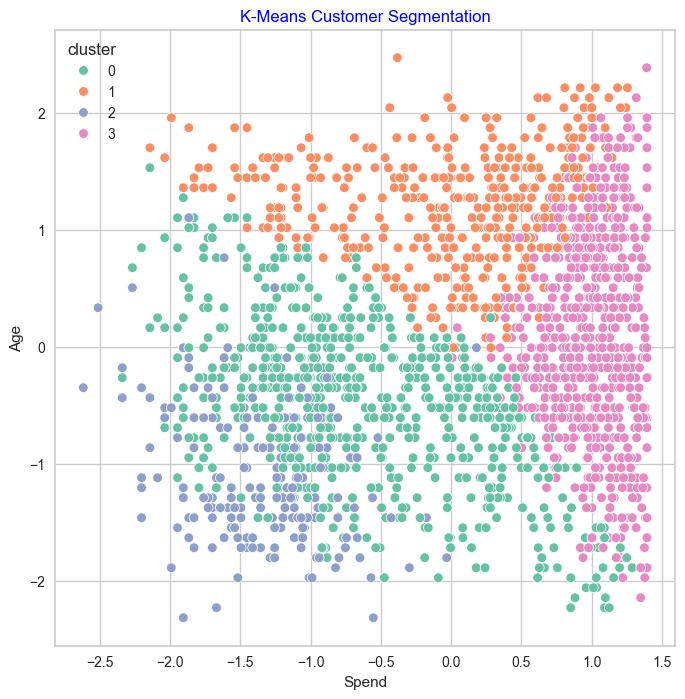

In [10]:
## Biểu diễn trực quan
plt.figure(figsize = (8, 8))
sns.scatterplot(
    x=data['Total_Spend'],
    y=data['Age'],
    hue=data['cluster'],palette="Set2"
)
plt.xlabel('Spend')
plt.ylabel('Age')
plt.title("K-Means Customer Segmentation", color = "blue")
plt.show()

In [11]:
pca=PCA(n_components=2)
pca.fit(data)
PCA_ds=pd.DataFrame(pca.transform(data),columns=(['col1','col2']))
print(PCA_ds.describe())

               col1          col2
count  2.229000e+03  2.229000e+03
mean   1.083825e-16 -5.498817e-17
std    1.681507e+00  9.951556e-01
min   -2.651014e+00 -2.605163e+00
25%   -1.471149e+00 -7.301749e-01
50%   -3.668070e-01 -1.033873e-02
75%    1.833727e+00  7.392326e-01
max    3.150066e+00  2.450237e+00


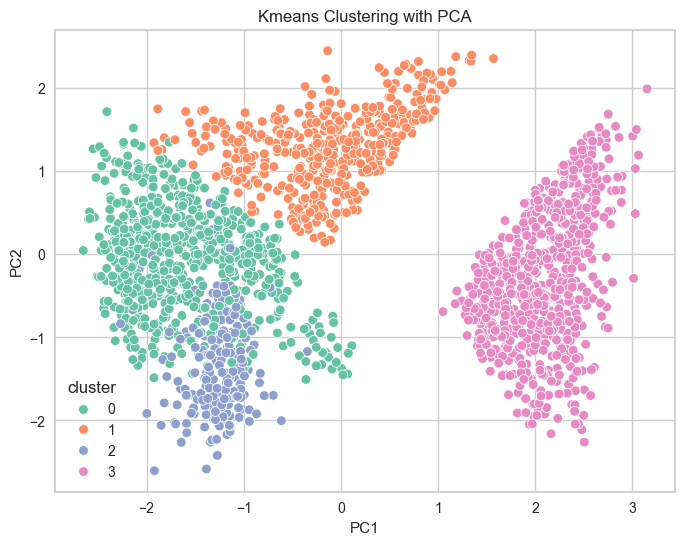

In [12]:

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=PCA_ds['col1'],
    y=PCA_ds['col2'],
    hue=data['cluster'],
    palette='Set2'
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Kmeans Clustering with PCA')
plt.show()